# Tarea - Stitching de imágenes

> Inteligencia Artificial y mini-Robots
> Prof. Flavio Prieto
> Estudiante: **Alejandro Jiménez Zabala**

## Objetivo

Diseñar un sistema capaz de generar una imágen panoramica coherente a partir de múltiples imágenes con solapamiento, mediante técnicas de visión por computador.

## Imágenes originales

![Ellie1](images/Ellie1.jpg)
![Ellie2](images/Ellie2.jpg)
![Flores1](images/Flores1.jpg)
![Flores2](images/Flores2.jpg)
![Salon1](images/Salon1.jpg)
![Salon2](images/Salon2.jpg)

## Librerías

Con las librerias de OpenCv, Numpy, y matplotlib instaladas (eg. `pip install opencv-python`), son importadas en el notebook y se prueba su funcionamiento.

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print(cv2.__version__)
print(np.__version__)
print(plt.matplotlib.__version__)

4.13.0
2.4.6
3.10.9


## Funciones

### Inicio de SIFT

Para cumplir con el objetivo de la tarea, se recurre a usar el método SIFT, ya que es el método con mejor capacidad de dar resultados buenos, y está integrado en la librería abierta de OpenCV. El método SIFT tiene la desventaja que es más lento que otras opciones, pero dicho criterio de la rapidez de procesamiento no se le da mayor prioridad en el cumplimiento de los objetivos de la tarea.

Se inicia entonces con una función para el cambio de color de la imagen a escala de grises, para posteriormente hacer la detección de los keypoints, y cálculo de descriptores usando SIFT.

In [18]:
def detectar_y_describir(image):

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    sift = cv2.SIFT_create()

    keypoints, descriptores = sift.detectAndCompute(gray, None)

    return keypoints, descriptores

### Realización de uniones (Matching)

Se usa BFMatcher junto con el test de Lowe, como se vio en clase.

$$
\frac{d_{mejor}}{d_{segundo}} < 0.75
$$

In [19]:
def matching(desc1, desc2):

    bf = cv2.BFMatcher(cv2.NORM_L2)

    matches = bf.knnMatch(desc1, desc2, k=2)

    good = []

    for m, n in matches:

        if m.distance < 0.75 * n.distance:
            good.append(m)

    return good

### Homografía con RANSAC

In [20]:
def homografia(kp1, kp2, matches):

    puntos_img1 = np.float32(
        [kp1[m.queryIdx].pt for m in matches]
    ).reshape(-1, 1, 2)

    puntos_img2 = np.float32(
        [kp2[m.trainIdx].pt for m in matches]
    ).reshape(-1, 1, 2)

    H, mascara = cv2.findHomography(
        puntos_img1,
        puntos_img2,
        cv2.RANSAC,
        5.0
    )

    return H, mascara

### Creación de imagen

Se aplica tambien warping para generar la imagen resultante, además de definir una función independiente como comando para mostrar dicha imágen.

In [21]:
def crear_panorama(img1, img2, H):
    
    alto1, ancho1 = img1.shape[:2]
    alto2, ancho2 = img2.shape[:2]

    esquinas_img1 = np.float32([
        [0, 0],
        [0, alto1],
        [ancho1, alto1],
        [ancho1, 0]
    ]).reshape(-1, 1, 2)

    esquinas_transformadas = cv2.perspectiveTransform(
        esquinas_img1,
        H
    )

    esquinas_img2 = np.float32([
        [0, 0],
        [0, alto2],
        [ancho2, alto2],
        [ancho2, 0]
    ]).reshape(-1, 1, 2)

    todas_esquinas = np.concatenate(
        (esquinas_transformadas, esquinas_img2),
        axis=0
    )

    [xmin, ymin] = np.int32(
        todas_esquinas.min(axis=0).ravel() - 0.5
    )

    [xmax, ymax] = np.int32(
        todas_esquinas.max(axis=0).ravel() + 0.5
    )

    translacion = [-xmin, -ymin]

    H_translacion = np.array([
        [1, 0, translacion[0]],
        [0, 1, translacion[1]],
        [0, 0, 1]
    ])

    panorama = cv2.warpPerspective(
        img1,
        H_translacion @ H,
        (xmax - xmin, ymax - ymin)
    )

    panorama[
        translacion[1]:alto2 + translacion[1],
        translacion[0]:ancho2 + translacion[0]
    ] = img2

    return panorama

def mostrar_imagen(titulo, imagen):

    imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(15, 8))
    plt.title(titulo)
    plt.imshow(imagen_rgb)
    plt.axis("off")
    plt.show()

## Ejecución principal

Con las funciones a aplicar ya definidas, se puede proceder a cargar las imágenes para aplicar el stitching, aplicando una a una las funciones previamente definidas.

Keypoints imagen 1: 20246
Keypoints imagen 2: 18618


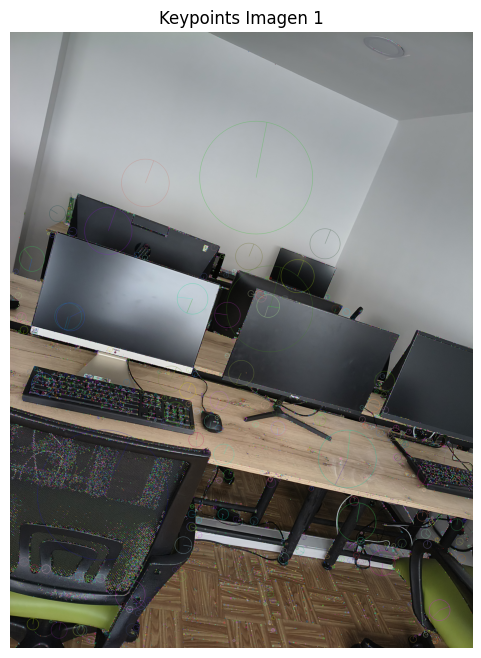

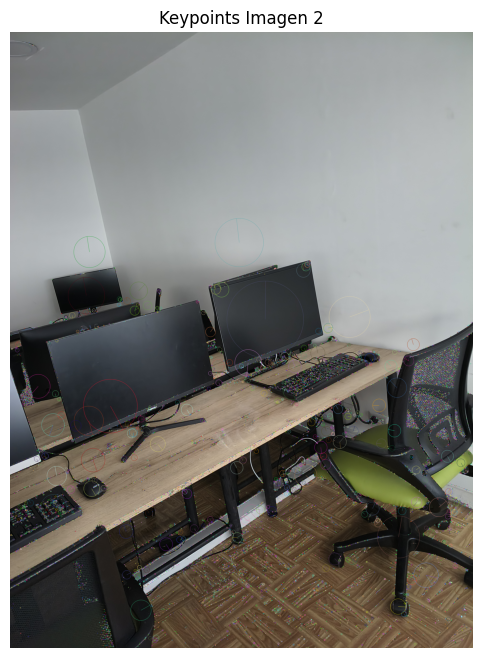

Matches buenos: 1218


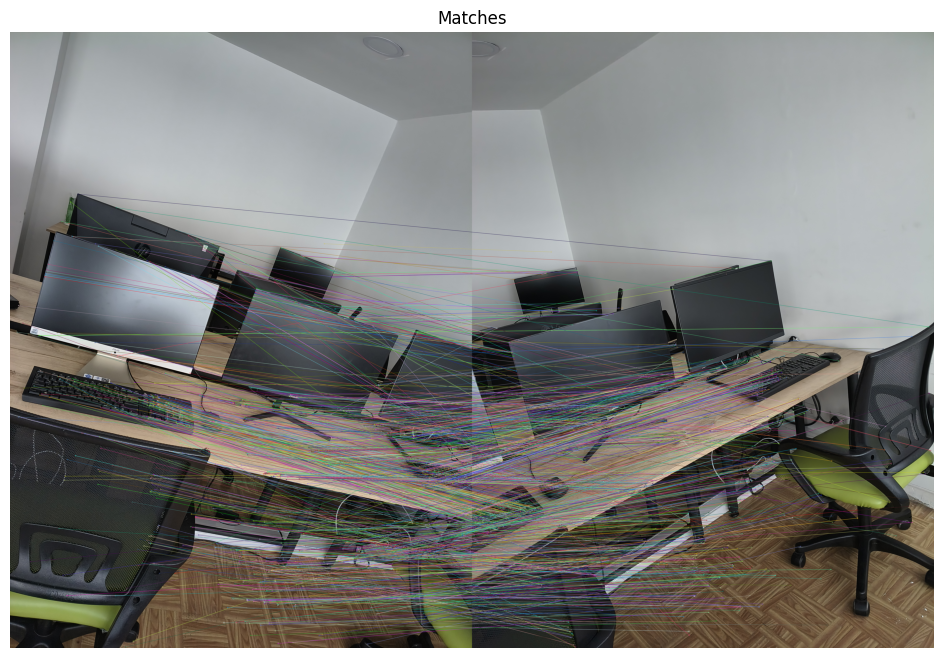

Homografía:
[[ 1.41185140e+00  8.65022590e-01 -3.37001623e+03]
 [-5.45045933e-01  1.47866471e+00  1.10050494e+03]
 [ 1.71055505e-04  6.10221785e-05  1.00000000e+00]]


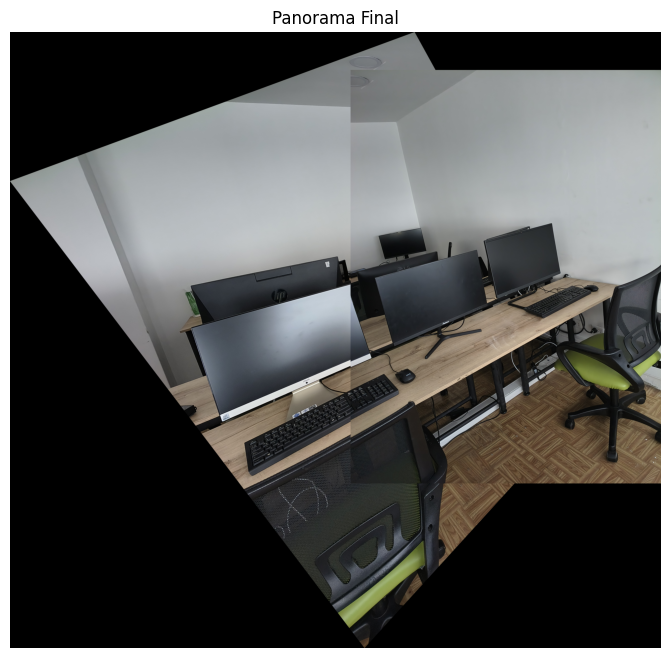

True

In [24]:
img1 = cv2.imread("images/Salon1.jpg")
img2 = cv2.imread("images/Salon2.jpg")

# Detección y dibujo de puntos clave (keypoints)

kp1, desc1 = detectar_y_describir(img1)
kp2, desc2 = detectar_y_describir(img2)

print(f"Keypoints imagen 1: {len(kp1)}")
print(f"Keypoints imagen 2: {len(kp2)}")

img_kp1 = cv2.drawKeypoints(
    img1,
    kp1,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

img_kp2 = cv2.drawKeypoints(
    img2,
    kp2,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

mostrar_imagen("Keypoints Imagen 1", img_kp1)
mostrar_imagen("Keypoints Imagen 2", img_kp2)

# Matching

matches_buenos = matching(desc1, desc2)

print(f"Matches buenos: {len(matches_buenos)}")

img_matches = cv2.drawMatches(
    img1,
    kp1,
    img2,
    kp2,
    matches_buenos,
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

mostrar_imagen("Matches", img_matches)

# Homografía

H, mascara = homografia(
    kp1,
    kp2,
    matches_buenos
)

print("Homografía:")
print(H)

# Stitching final

panorama = crear_panorama(img1, img2, H)

mostrar_imagen("Panorama Final", panorama)

cv2.imwrite("images/panorama_resultado_salon.jpg", panorama)

## Resultados

Se inicia con dos fotos de mi mascota, una border collie negra, pero no se consigue un stitching adecuado, lo que se puede atribuir a el poco solapamiento que existe entre las dos fotos originales, por lo que no hubo suficientes similitudes para el panorama final.

![Ellie](images/panorama_resultado_ellie.jpg)

Para el segundo caso, de unas fotos de unas flores, mejora el el solapamiento, pero hay una falta de puntos clave o keypoints cuando se hace que los reconozca con una escala de grises, dado que no son muchos los elementos a analizar en las imagenes, se dificulta el reconocimiento de contornos, por lo que no hay mucha información sobre los puntos a unir.

![Flores](images/panorama_resultado_flores.jpg)

Ya para el ultimo caso, de un salón, y reconociendo las limitaciones de solapamiento, y datos a procesar, se obtiene el mejor resultado, de entre las pruebas realizadas.

![Salon](images/panorama_resultado_salon.jpg)